In [ ]:
import os
import h5py
import pandas as pd
import numpy as np

def extract_pure_earthquake_data(
    master_csv_path, 
    master_hdf5_path, 
    mcquake_meta_path, 
    output_dir, 
    num_samples=10000
):
    print("=" * 80)
    print(" EKSTRAKSI ULANG 10.000 DATA STEAD KHUSUS GEMPA (100% EVENT)")
    print("=" * 80)
    
    # 1. Validasi Path File Sumber
    for path, name in [
        (master_csv_path, "Master CSV"), 
        (master_hdf5_path, "Master HDF5"), 
        (mcquake_meta_path, "MCU-Quake Meta CSV")
    ]:
        if not os.path.exists(path):
            print(f"[ERROR] {name} tidak ditemukan di path: {path}")
            return

    os.makedirs(output_dir, exist_ok=True)
    print(f"[INFO] Direktori penyimpanan output: {output_dir}")

    # 2. Memuat daftar trace yang sudah digunakan oleh MCU-Quake (Pengecualian)
    print("Membaca metadata MCU-Quake untuk proses pengecualian...")
    df_mcquake = pd.read_csv(mcquake_meta_path)
    exclude_traces = set(df_mcquake['trace_name'].astype(str)) if 'trace_name' in df_mcquake.columns else set()
    print(f"[INFO] Total trace di MCU-Quake yang akan di-skip: {len(exclude_traces):,} trace.")

    # 3. Memuat Master CSV STEAD
    print("Membaca master data CSV STEAD...")
    df_master = pd.read_csv(master_csv_path)
    df_master = df_master.dropna(subset=['trace_name'])

    # 4. FILTER KETAT: Hanya ambil kategori 'earthquake_local' dan buang yang ada di MCU-Quake
    print("Menerapkan filter kategori 'earthquake_local' dan pengecualian MCU-Quake...")
    
    # Filter kategori gempa
    if 'trace_category' in df_master.columns:
        df_quakes = df_master[df_master['trace_category'] == 'earthquake_local']
    else:
        df_quakes = df_master

    # Filter pengecualian
    df_available = df_quakes[~df_quakes['trace_name'].astype(str).isin(exclude_traces)]
    print(f"[INFO] Sisa data gempa murni yang tersedia: {len(df_available):,} baris.")

    if len(df_available) < num_samples:
        print(f"[PERINGATAN] Data tersedia ({len(df_available):,}) kurang dari target ({num_samples:,}). Mengambil semua sisa data.")
        num_samples = len(df_available)

    # Ambil sampel secara acak dengan cadangan untuk mengantisipasi data korup
    candidate_pool_size = min(int(num_samples * 1.5), len(df_available))
    df_candidates = df_available.sample(n=candidate_pool_size, random_state=42).reset_index(drop=True)

    # 5. Proses Ekstraksi HDF5 & Pembuatan CSV Baru
    output_hdf5_path = os.path.join(output_dir, "stead_raw_10k_waveforms.hdf5")
    output_csv_path = os.path.join(output_dir, "stead_raw_10k_meta.csv")

    valid_metadata = []
    
    print("Membuka arsip HDF5 master dan mengekstrak gelombang event murni...")
    with h5py.File(master_hdf5_path, 'r') as h5_in, h5py.File(output_hdf5_path, 'w') as h5_out:
        group_keys = list(h5_in.keys())
        target_group = 'earthquake' if 'earthquake' in group_keys else group_keys[0]
        
        in_group = h5_in[target_group]
        out_group = h5_out.create_group(target_group)
        
        success_count = 0
        skipped_count = 0
        
        for idx, row in df_candidates.iterrows():
            if success_count >= num_samples:
                break
                
            trace_name = str(row['trace_name'])
            
            if trace_name in in_group:
                try:
                    waveform_arr = in_group[trace_name][:]
                    
                    # Validasi anti-korup (NaN, Inf, atau dimensi kurang)
                    if np.isnan(waveform_arr).any() or np.isinf(waveform_arr).any():
                        skipped_count += 1
                        continue
                    if waveform_arr.shape[0] < 6000 or waveform_arr.shape[1] < 3:
                        skipped_count += 1
                        continue

                    # Simpan ke HDF5 baru
                    out_group.create_dataset(trace_name, data=waveform_arr)
                    valid_metadata.append(row.to_dict())
                    success_count += 1
                    
                    if success_count % 1000 == 0:
                        print(f"  -> Berhasil diekstrak: {success_count:,} / {num_samples:,} sampel gempa...")
                        
                except Exception:
                    skipped_count += 1
                    continue

    # Simpan metadata bersih ke CSV
    df_output_meta = pd.DataFrame(valid_metadata)
    df_output_meta.to_csv(output_csv_path, index=False)
    
    print("=" * 80)
    print("[SUKSES] Ekstraksi ulang 100% data event gempa selesai!")
    print(f" • Target Terpenuhi   : {success_count:,} / {num_samples:,} sampel")
    print(f" • File HDF5 Output   : {output_hdf5_path}")
    print(f" • File CSV Metadata  : {output_csv_path}")
    print("=" * 80)

if __name__ == "__main__":
    # Konfigurasi Path Sesuai Direktori Anda
    MASTER_CSV = "/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv"
    MASTER_HDF5 = "/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5"
    MCQUAKE_EXCLUDE_CSV = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD 3C meta, test SNR_DB, n15275.csv"
    OUTPUT_DIRECTORY = "/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead"

    extract_pure_earthquake_data(
        master_csv_path=MASTER_CSV,
        master_hdf5_path=MASTER_HDF5,
        mcquake_meta_path=MCQUAKE_EXCLUDE_CSV,
        output_dir=OUTPUT_DIRECTORY,
        num_samples=10000
    )

In [ ]:
import os
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def comprehensive_investigation(hdf5_path, csv_path):
    print("=" * 80)
    print(" INVESTIGASI KOMPREHENSIF DATA STEAD 10.000")
    print("=" * 80)
    
    # 1. Validasi File
    if not os.path.exists(hdf5_path) or not os.path.exists(csv_path):
        print(f"[ERROR] File HDF5 atau CSV tidak ditemukan!")
        print(f" • CSV Path : {csv_path}")
        print(f" • HDF5 Path: {hdf5_path}")
        return

    # 2. Memuat dan Menganalisis Metadata CSV
    print("Membaca file metadata CSV...")
    df = pd.read_csv(csv_path)
    print(f"[INFO] Total record metadata yang dimuat: {len(df):,} baris.\n")

    print("--- 1. ANALISIS STATISTIK PARAMETER GEMPA ---")
    cols_to_check = ['source_magnitude', 'source_distance_km', 'source_depth_km']
    for col in cols_to_check:
        if col in df.columns:
            clean_data = df[col].dropna()
            print(f" • {col:<20} | Min: {clean_data.min():.2f} | Max: {clean_data.max():.2f} | Mean: {clean_data.mean():.2f}")

    # Cek sebaran tipe magnitudo
    if 'source_magnitude_type' in df.columns:
        print("\n--- 2. DISTRIBUSI TIPE MAGNITUDO ---")
        print(df['source_magnitude_type'].value_counts().to_string())

    # 3. Memeriksa Integritas Waveform HDF5
    print("\n--- 3. ANALISIS INTEGRITAS WAVEFORM HDF5 ---")
    with h5py.File(hdf5_path, 'r') as h5_file:
        group_keys = list(h5_file.keys())
        target_group = 'earthquake' if 'earthquake' in group_keys else group_keys[0]
        waveform_group = h5_file[target_group]
        
        trace_names = list(waveform_group.keys())
        print(f" • Total trace dalam HDF5 : {len(trace_names):,}")
        
        # Ambil contoh sampel pertama
        sample_name = trace_names[0]
        sample_wave = waveform_group[sample_name][:]
        print(f" • Contoh Trace Nama     : {sample_name}")
        print(f" • Bentuk Matriks (Shape): {sample_wave.shape} (6000 sampel x 3 komponen)")
        print(f" • Cek Nilai Kosong/NaN  : {np.isnan(sample_wave).any()}")

    # 4. Membuat Plot Visualisasi Seismogram 60 Detik
    print("\n--- 4. MENYIAPKAN GRAFIK VISUALISASI SEISMOGRAM ---")
    plt.figure(figsize=(14, 8))
    
    # Resolusi 100 Hz -> 6000 sampel = 60 detik
    time_axis = np.arange(sample_wave.shape[0]) / 100.0 
    
    components = ['Komponen E (East-West)', 'Komponen N (North-South)', 'Komponen Z (Vertical)']
    colors = ['tab:red', 'tab:blue', 'green']  # Diperbaiki dari 'tab:darkgreen' ke 'green'
    
    for i in range(min(3, sample_wave.shape[1])):
        plt.subplot(3, 1, i + 1)
        plt.plot(time_axis, sample_wave[:, i], color=colors[i], linewidth=0.7)
        plt.ylabel(f"Amplitudo\n{components[i]}", fontsize=9)
        plt.grid(True, linestyle='--', alpha=0.6)
        if i == 2:
            plt.xlabel("Waktu (detik)", fontsize=10)

    plt.suptitle(f"Seismogram Asli STEAD 60 Detik - Trace ID: {sample_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    output_image = "investigasi_stead_10k_waveform.png"
    plt.savefig(output_image, dpi=300)
    print(f"[SUKSES] Grafik berhasil disimpan sebagai '{output_image}' di direktori kerja Anda.")
    plt.show()

if __name__ == "__main__":
    # Konfigurasi Path Sesuai Direktori Penyimpanan Anda
    HDF5_FILE = "/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/stead_raw_10k_waveforms.hdf5"
    CSV_FILE = "/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/stead_raw_10k_meta.csv"

    comprehensive_investigation(HDF5_FILE, CSV_FILE)

In [ ]:
import os
import h5py
import pandas as pd
import numpy as np

def quick_align_existing_data(
    existing_csv_path,
    existing_hdf5_path,
    mcquake_ref_csv_path,
    output_dir,
    target_length=1000
):
    print("=" * 80)
    print("PENYELARASAN CEPAT FILE 10K YANG SUDAH ADA KE FORMAT MCU-QUAKE")
    print("=" * 80)
    
    if not os.path.exists(existing_csv_path) or not os.path.exists(existing_hdf5_path):
        print("[ERROR] File metadata atau HDF5 yang sudah ada tidak ditemukan!")
        return

    os.makedirs(output_dir, exist_ok=True)

    # 1. Ambil daftar 37 kolom acuan persis dari MCU-Quake
    df_ref = pd.read_csv(mcquake_ref_csv_path)
    target_columns = list(df_ref.columns)
    print(f"[INFO] Kolom acuan MCU-Quake dimuat: {len(target_columns)} kolom.")

    # 2. Muat metadata 10k yang sudah ada
    df_existing = pd.read_csv(existing_csv_path)
    print(f"[INFO] Memproses {len(df_existing):,} baris metadata yang sudah ada...")

    # Pastikan kolom 'index_o' ada
    if 'index_o' not in df_existing.columns:
        df_existing['index_o'] = df_existing.index

    output_hdf5_path = os.path.join(output_dir, "stead_mcquake_ready_waveforms.hdf5")
    output_csv_path = os.path.join(output_dir, "stead_mcquake_ready_meta.csv")

    aligned_metadata = []

    # 3. Proses HDF5 yang sudah ada (potong jadi 1000 sampel jika masih 6000)
    print("Menyesuaikan gelombang dan kolom metadata...")
    with h5py.File(existing_hdf5_path, 'r') as h5_in, h5py.File(output_hdf5_path, 'w') as h5_out:
        group_key = list(h5_in.keys())[0]
        in_group = h5_in[group_key]
        out_group = h5_out.create_group(group_key)
        
        for idx, row in df_existing.iterrows():
            trace_name = str(row['trace_name'])
            
            if trace_name in in_group:
                wave = in_group[trace_name][:]
                if wave.shape[0] == 3:
                    wave = wave.T
                
                # Ambil window standar MCU-Quake (1000 sampel)
                if wave.shape[0] >= target_length:
                    window_wave = wave[:target_length, :]
                else:
                    window_wave = wave
                
                # Simpan ke HDF5 baru
                out_group.create_dataset(trace_name, data=window_wave)
                
                # Penyelarasan Kolom Metadata
                row_dict = row.to_dict()
                if 'SNR_DB ZNE' not in row_dict or pd.isna(row_dict.get('SNR_DB ZNE')):
                    row_dict['SNR_DB ZNE'] = str(row_dict.get('snr_db', [15.0, 15.0, 15.0]))

                aligned_row = {}
                for col in target_columns:
                    aligned_row[col] = row_dict.get(col, np.nan)
                    
                aligned_metadata.append(aligned_row)

    # Simpan CSV hasil penyesuaian
    df_final = pd.DataFrame(aligned_metadata)
    df_final.to_csv(output_csv_path, index=False)

    print("=" * 80)
    print("[SUKSES] Penyelarasan selesai tanpa ekstraksi ulang!")
    print(f" • File HDF5 Siap Benchmark : {output_hdf5_path}")
    print(f" • File CSV 37 Kolom Persis : {output_csv_path}")
    print("=" * 80)

if __name__ == "__main__":
    # Direktori file 10k Anda saat ini
    DATA_DIR = "/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead"
    EXISTING_CSV = os.path.join(DATA_DIR, "stead_raw_10k_meta.csv")
    EXISTING_HDF5 = os.path.join(DATA_DIR, "stead_raw_10k_waveforms.hdf5")
    
    # Path Acuan MCU-Quake untuk Meniru 37 Kolom
    MCQUAKE_REF_CSV = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD 3C meta, test SNR_DB, n15275.csv"

    quick_align_existing_data(
        existing_csv_path=EXISTING_CSV,
        existing_hdf5_path=EXISTING_HDF5,
        mcquake_ref_csv_path=MCQUAKE_REF_CSV,
        output_dir=DATA_DIR,
        target_length=1000
    )

In [ ]:
import os
import h5py
import pandas as pd
import numpy as np
import json

def generate_benchmark_json():
    DATA_DIR = '/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead'
    csv_path = os.path.join(DATA_DIR, "stead_mcquake_ready_meta.csv")
    hdf5_path = os.path.join(DATA_DIR, "stead_mcquake_ready_waveforms.hdf5")
    output_json_path = os.path.join(DATA_DIR, "STEAD_mcquake_benchmark_10k.json")

    print(f"Membaca metadata dari: {csv_path}")
    df = pd.read_csv(csv_path)
    
    benchmark_dict = {}
    
    print(f"Membaca waveform dari: {hdf5_path}")
    with h5py.File(hdf5_path, 'r') as h5_file:
        group_key = list(h5_file.keys())[0]
        group = h5_file[group_key]
        
        for idx, row in df.iterrows():
            trace_name = str(row['trace_name'])
            if trace_name in group:
                wave = group[trace_name][:] # Shape: (1000, 3) [E, N, Z] atau sebaliknya
                if wave.shape[0] == 3:
                    wave = wave.T
                
                # Asumsi urutan kanal: 0=E, 1=N, 2=Z
                e_chan = wave[:, 0].tolist()
                n_chan = wave[:, 1].tolist()
                z_chan = wave[:, 2].tolist()
                
                # Noise window (ambil bagian awal sebagai representasi noise pendahuluan)
                z_noise = z_chan[:300] if len(z_chan) >= 300 else z_chan
                n_noise = n_chan[:300] if len(n_chan) >= 300 else n_chan
                e_noise = e_chan[:300] if len(e_chan) >= 300 else e_chan
                
                norm_val = float(np.max(np.abs(wave)))
                if norm_val == 0 or np.isnan(norm_val):
                    norm_val = 1.0

                trace_id_str = str(row.get('index_o', trace_name))
                
                benchmark_dict[trace_id_str] = {
                    "type": "le",  # Local earthquake
                    "Z": z_chan,
                    "N": n_chan,
                    "E": e_chan,
                    "Z_noise": z_noise,
                    "N_noise": n_noise,
                    "E_noise": e_noise,
                    "norm": norm_val
                }

    print(f"Menyimpan file JSON ke: {output_json_path}")
    with open(output_json_path, 'w') as f_out:
        json.dump(benchmark_dict, f_out)
    print("[SUKSES] File JSON benchmark 10k berhasil dibuat!")

if __name__ == "__main__":
    generate_benchmark_json()

In [1]:
import os
import h5py
import json
import numpy as np
import pandas as pd
from tqdm import tqdm

# ===================================================================
# KONFIGURASI PATH
# ===================================================================
MCQUAKE_EXCLUDE_CSV = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD 3C meta, test SNR_DB, n15275.csv"

MASTER_CSV_PATH = "/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv"
MASTER_HDF5_PATH = "/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5"
OUTPUT_JSON_PATH = "/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/STEAD_mcquake_10k_filtered.json"

TARGET_SAMPLES = 700  # Panjang jendela mutlak untuk model (None, 700, 1)
NUM_TARGET_RECORDS = 10000

def extract_stead_excluding_list():
    print("=" * 80)
    print(" EKSTRAKSI 10K STEAD (MENGEKSLUSI DATA ZHI GENG & PRESISI 700 SAMPEL)")
    print("=" * 80)
    
    if not os.path.exists(MCQUAKE_EXCLUDE_CSV):
        print(f"[ERROR] File exclude CSV tidak ditemukan di:\n{MCQUAKE_EXCLUDE_CSV}")
        return
    if not os.path.exists(MASTER_CSV_PATH) or not os.path.exists(MASTER_HDF5_PATH):
        print(f"[ERROR] File master CSV/HDF5 tidak ditemukan di SSD eksternal!")
        return

    print("[INFO] Membaca daftar trace yang harus dikecualikan (exclude)...")
    df_exclude = pd.read_csv(MCQUAKE_EXCLUDE_CSV)
    exclude_col = 'trace_name' if 'trace_name' in df_exclude.columns else df_exclude.columns[0]
    excluded_traces = set(df_exclude[exclude_col].astype(str))
    print(f"[INFO] Jumlah trace yang akan di-exclude: {len(excluded_traces):,}")

    print("[INFO] Membaca metadata master CSV STEAD...")
    df_master = pd.read_csv(MASTER_CSV_PATH)
    
    # Filter hanya gempa lokal dan pastikan kolom trace_name serta p_arrival_sample ada
    if 'trace_category' in df_master.columns:
        df_quakes = df_master[df_master['trace_category'] == 'earthquake_local'].dropna(subset=['trace_name', 'p_arrival_sample'])
    else:
        df_quakes = df_master.dropna(subset=['trace_name'])

    # Hapus trace yang masuk ke dalam daftar exclude Zhi Geng
    print("[INFO] Menyaring master data dengan menyingkirkan trace yang di-exclude...")
    df_filtered = df_quakes[~df_quakes['trace_name'].astype(str).isin(excluded_traces)].reset_index(drop=True)
    print(f"[INFO] Sisa data gempa lokal yang valid setelah exclude: {len(df_filtered):,}")

    # Ambil sampel secara acak sebanyak 10.000 data
    if len(df_filtered) > NUM_TARGET_RECORDS:
        df_subset = df_filtered.sample(n=NUM_TARGET_RECORDS, random_state=42).reset_index(drop=True)
    else:
        print(f"[PERINGATAN] Data tersedia ({len(df_filtered):,}) kurang dari {NUM_TARGET_RECORDS}, mengambil seluruhnya.")
        df_subset = df_filtered.reset_index(drop=True)

    benchmark_data_dict = {}
    success_count = 0
    skipped_count = 0

    print(f"[INFO] Memproses HDF5 master lokal dan memotong jendela ke {TARGET_SAMPLES} sampel...")
    
    with h5py.File(MASTER_HDF5_PATH, 'r') as h5_file:
        group_keys = list(h5_file.keys())
        target_group = 'earthquake' if 'earthquake' in group_keys else group_keys[0]
        waveform_group = h5_file[target_group]
        
        for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset), desc="Ekstraksi Waveform"):
            trace_name = str(row['trace_name'])
            
            if trace_name in waveform_group:
                try:
                    raw_wave = waveform_group[trace_name][:] # Bentuk master (6000, 3)
                    
                    if raw_wave.shape[0] == 3:
                        raw_wave = raw_wave.T # Normalisasi ke bentuk (N, 3)
                        
                    p_sample = int(row['p_arrival_sample'])
                    start_idx = p_sample
                    end_idx = p_sample + TARGET_SAMPLES
                    
                    if start_idx < 0 or end_idx > raw_wave.shape[0]:
                        skipped_count += 1
                        continue
                        
                    wave_window = raw_wave[start_idx:end_idx, :]
                    
                    # Proteksi padding nol jika kurang dari 700 sampel
                    if wave_window.shape[0] < TARGET_SAMPLES:
                        pad_size = TARGET_SAMPLES - wave_window.shape[0]
                        wave_window = np.pad(wave_window, ((0, pad_size), (0, 0)), 'constant', constant_values=0.0)

                    # Pisahkan kanal (0=E, 1=N, 2=Z)
                    e_chan = wave_window[:, 0].astype(np.float32).tolist()
                    n_chan = wave_window[:, 1].astype(np.float32).tolist()
                    z_chan = wave_window[:, 2].astype(np.float32).tolist()
                    
                    # Noise window (200 sampel sebelum P-arrival)
                    noise_start = max(0, p_sample - 200)
                    noise_end = p_sample
                    z_noise = raw_wave[noise_start:noise_end, 2].astype(np.float32).tolist()
                    n_noise = raw_wave[noise_start:noise_end, 1].astype(np.float32).tolist()
                    e_noise = raw_wave[noise_start:noise_end, 0].astype(np.float32).tolist()
                    
                    norm_val = float(np.max(np.abs(wave_window)))
                    if norm_val == 0 or np.isnan(norm_val):
                        norm_val = 1.0

                    trace_id_str = str(row.get('index_o', trace_name))
                    
                    benchmark_data_dict[trace_id_str] = {
                        "type": "le",
                        "Z": z_chan,
                        "N": n_chan,
                        "E": e_chan,
                        "Z_noise": z_noise,
                        "N_noise": n_noise,
                        "E_noise": e_noise,
                        "norm": norm_val,
                        "magnitude": float(row.get('source_magnitude', 0.0)),
                        "distance_km": float(row.get('source_distance_km', 0.0))
                    }
                    
                    success_count += 1
                except Exception:
                    skipped_count += 1
                    continue
            else:
                skipped_count += 1

    # Simpan hasil akhir ke file JSON target
    os.makedirs(os.path.dirname(OUTPUT_JSON_PATH), exist_ok=True)
    print(f"\n[INFO] Menyimpan file JSON benchmark ke:\n{OUTPUT_JSON_PATH}")
    with open(OUTPUT_JSON_PATH, 'w') as f_out:
        json.dump(benchmark_data_dict, f_out)
        
    print("=" * 80)
    print(f"[SUKSES] Ekstraksi Selesai!")
    print(f" • Total Trace Berhasil Disimpan : {success_count:,}")
    print(f" • Total Trace Dieksklusi/Dilewati: {skipped_count:,}")
    print(f" • Dimensi Waktu Tiap Trace      : {TARGET_SAMPLES} sampel (Kompatibel Model)")
    print("=" * 80)

if __name__ == "__main__":
    extract_stead_excluding_list()

 EKSTRAKSI 10K STEAD (MENGEKSLUSI DATA ZHI GENG & PRESISI 700 SAMPEL)
[INFO] Membaca daftar trace yang harus dikecualikan (exclude)...
[INFO] Jumlah trace yang akan di-exclude: 15,275
[INFO] Membaca metadata master CSV STEAD...


/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_8919/1102180284.py:39: DtypeWarning: Columns (0: p_status, 1: s_status, 2: source_id, 3: source_origin_time, 4: source_magnitude_type, 5: source_magnitude_author, 6: source_mechanism_strike_dip_rake, 7: snr_db, 8: coda_end_sample) have mixed types. Specify dtype option on import or set low_memory=False.
  df_master = pd.read_csv(MASTER_CSV_PATH)


[INFO] Menyaring master data dengan menyingkirkan trace yang di-exclude...
[INFO] Sisa data gempa lokal yang valid setelah exclude: 1,014,956
[INFO] Memproses HDF5 master lokal dan memotong jendela ke 700 sampel...


Ekstraksi Waveform: 100%|██████████| 10000/10000 [02:17<00:00, 72.88it/s]



[INFO] Menyimpan file JSON benchmark ke:
/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/STEAD_mcquake_10k_filtered.json
[SUKSES] Ekstraksi Selesai!
 • Total Trace Berhasil Disimpan : 10,000
 • Total Trace Dieksklusi/Dilewati: 0
 • Dimensi Waktu Tiap Trace      : 700 sampel (Kompatibel Model)


In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
EKSTRAKSI 10.000 SAMPEL ACAK STEAD UNTUK MCU-QUAKE
- Mengecualikan trace yang digunakan oleh Zhi Geng (n15275).
- Distribusi seimbang: 5.000 Gempa (EV), 5.000 Noise (NO).
- Demean / Detrending diterapkan sebelum normalisasi.
- Jendela tepat 700 sampel (7 detik @ 100Hz).
- Penanganan khusus untuk kolom snr_db yang berbentuk string array.
- Menyimpan ke dalam format JSON 1C dan 3C.
"""

import os
import json
import numpy as np
import pandas as pd
import h5py
import re
from tqdm import tqdm
from datetime import datetime

# ===================================================================
# 1. KONFIGURASI DIREKTORI & PARAMETER
# ===================================================================
# Sesuaikan dengan path Anda
MASTER_CSV_PATH = "/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv"
MASTER_HDF5_PATH = "/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5"
MCQUAKE_EXCLUDE_CSV = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD 3C meta, test SNR_DB, n15275.csv"
OUTPUT_DIR = "/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_10000"

SAMPLE_RATE = 100.0
SIG_DURATION = 7.0
NOISE_DURATION = 7.0
NORM_WINDOW = 9.0
TARGET_LEN = int(SAMPLE_RATE * SIG_DURATION)  # 700

N_SAMPLES = 10000
RANDOM_SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ===================================================================
# 2. FUNGSI PEMBANTU (HELPER FUNCTIONS)
# ===================================================================
def parse_snr(snr_val):
    """
    Membersihkan string array SNR (cth: '[19.2 15.0 15.5]') dari STEAD
    dan mengembalikan nilai rata-ratanya sebagai float.
    """
    if pd.isna(snr_val) or str(snr_val).strip() == '':
        return 0.0
        
    snr_str = str(snr_val).strip()
    
    # Coba langsung ubah jika bentuknya sudah angka (skalar)
    try:
        return float(snr_str)
    except ValueError:
        pass
        
    # Jika berbentuk list string, hapus kurung siku
    clean_str = re.sub(r'[\[\]]', '', snr_str)
    parts = clean_str.split()
    
    if len(parts) > 0:
        try:
            # Mengambil rata-rata dari ketiga komponen SNR
            return sum(float(x) for x in parts) / len(parts)
        except ValueError:
            return 0.0
    return 0.0

def extract_windows_ev(waveform, p_idx):
    """Ekstraksi untuk kategori Gempa (Earthquake) berdasarkan P-arrival."""
    p_idx = int(p_idx)
    # STEAD HDF5 shape (6000, 3) -> Komponen: 0=E, 1=N, 2=Z
    wf = waveform.T 
    wf = np.array([wf[2, :], wf[1, :], wf[0, :]])  # Kini indeks 0=Z, 1=N, 2=E
    
    sig_start = p_idx
    sig_end = p_idx + TARGET_LEN
    noise_start = max(0, p_idx - TARGET_LEN)
    noise_end = p_idx
    
    # Slicing
    if sig_end <= wf.shape[1]:
        signal = wf[:, sig_start:sig_end]
    else:
        signal = wf[:, sig_start:]
    noise = wf[:, noise_start:noise_end]
    
    # Padding
    if signal.shape[1] < TARGET_LEN:
        signal = np.pad(signal, ((0,0), (0, TARGET_LEN - signal.shape[1])), 'constant')
    if noise.shape[1] < TARGET_LEN:
        noise = np.pad(noise, ((0,0), (TARGET_LEN - noise.shape[1], 0)), 'constant')
        
    # Demean / Detrending (Penting!)
    signal = signal - np.mean(signal, axis=1, keepdims=True)
    noise = noise - np.mean(noise, axis=1, keepdims=True)
    
    # Normalisasi (Max absolut dari 9 detik)
    norm_end = min(wf.shape[1], p_idx + int(NORM_WINDOW * SAMPLE_RATE))
    if norm_end > p_idx:
        norm_win = wf[:, p_idx:norm_end]
        norm_win = norm_win - np.mean(norm_win, axis=1, keepdims=True) # Demean window norm
        max_val = np.max(np.abs(norm_win))
    else:
        max_val = np.max(np.abs(signal))
        
    if np.isnan(max_val) or max_val < 1e-6:
        max_val = 1.0
    
    signal_norm = signal / max_val
    noise_norm = noise / max_val
    
    return (signal_norm[0].tolist(), signal_norm[1].tolist(), signal_norm[2].tolist(),
            noise_norm[0].tolist(), noise_norm[1].tolist(), noise_norm[2].tolist())

def extract_windows_noise(waveform):
    """Ekstraksi untuk kategori Noise. (7 detik awal sinyal, 7 detik selanjutnya noise)."""
    wf = waveform.T
    wf = np.array([wf[2, :], wf[1, :], wf[0, :]])  # Z, N, E
    
    signal = wf[:, 0:TARGET_LEN]
    noise = wf[:, TARGET_LEN:2*TARGET_LEN]
    
    # Padding
    if signal.shape[1] < TARGET_LEN:
        signal = np.pad(signal, ((0,0), (0, TARGET_LEN - signal.shape[1])), 'constant')
    if noise.shape[1] < TARGET_LEN:
        noise = np.pad(noise, ((0,0), (TARGET_LEN - noise.shape[1], 0)), 'constant')
        
    # Demean / Detrending
    signal = signal - np.mean(signal, axis=1, keepdims=True)
    noise = noise - np.mean(noise, axis=1, keepdims=True)
    
    # Normalisasi
    max_val = np.max(np.abs(signal))
    if np.isnan(max_val) or max_val < 1e-6:
        max_val = 1.0
    
    signal_norm = signal / max_val
    noise_norm = noise / max_val
    
    return (signal_norm[0].tolist(), signal_norm[1].tolist(), signal_norm[2].tolist(),
            noise_norm[0].tolist(), noise_norm[1].tolist(), noise_norm[2].tolist())


# ===================================================================
# 3. BACA DAFTAR TRACE EXCLUDE (ZHI GENG)
# ===================================================================
print("="*80)
print("🚫 MEMBACA DAFTAR TRACE EXCLUDE (ZHI GENG n15275)")
print("="*80)

if os.path.exists(MCQUAKE_EXCLUDE_CSV):
    df_exclude = pd.read_csv(MCQUAKE_EXCLUDE_CSV)
    exclude_col = 'trace_name' if 'trace_name' in df_exclude.columns else df_exclude.columns[0]
    excluded_traces = set(df_exclude[exclude_col].astype(str))
    print(f"✅ Total trace yang akan dieksklusi: {len(excluded_traces):,}")
else:
    print(f"⚠️ Peringatan: File exclude tidak ditemukan! Melanjutkan tanpa filter pengecualian.")
    excluded_traces = set()


# ===================================================================
# 4. BACA & FILTER METADATA MASTER (CSV)
# ===================================================================
print("\n" + "="*80)
print("📂 MEMBACA DAN MEMFILTER METADATA MASTER STEAD")
print("="*80)

try:
    df = pd.read_csv(MASTER_CSV_PATH, low_memory=False)
except Exception:
    df = pd.read_csv(MASTER_CSV_PATH, engine='python')

print(f"📊 Total baris master awal: {len(df):,}")

needed_cols = [
    'trace_name', 'trace_category', 'p_arrival_sample', 's_arrival_sample',
    'source_origin_time', 'source_magnitude', 'source_latitude', 'source_longitude',
    'network_code', 'receiver_code', 'snr_db'
]
available_cols = [col for col in needed_cols if col in df.columns]
df = df[available_cols]

# Filter kategori gempa dan noise
mask_ev = (df['trace_category'] == 'earthquake_local') & df['p_arrival_sample'].notna()
mask_no = (df['trace_category'] == 'noise')

df = df[mask_ev | mask_no]

# Terapkan filter exclude
df = df[~df['trace_name'].astype(str).isin(excluded_traces)]

print(f"✅ Sisa baris valid setelah filter & exclude: {len(df):,}")
if len(df) == 0:
    print("❌ ERROR: Tidak ada data yang tersisa.")
    exit()

# ===================================================================
# 5. SAMPLING ACAK SEIMBANG (50/50)
# ===================================================================
print("\n" + "="*80)
print(f"🎲 MEMILIH {N_SAMPLES:,} SAMPEL ACAK SEIMBANG")
print("="*80)

df_ev = df[df['trace_category'] == 'earthquake_local']
df_no = df[df['trace_category'] == 'noise']

target_ev = N_SAMPLES // 2
target_no = N_SAMPLES - target_ev

if len(df_ev) < target_ev:
    target_ev = len(df_ev)
    target_no = N_SAMPLES - target_ev
if len(df_no) < target_no:
    target_no = len(df_no)
    target_ev = N_SAMPLES - target_no

selected_ev = df_ev.sample(n=target_ev, random_state=RANDOM_SEED) if target_ev > 0 else pd.DataFrame()
selected_no = df_no.sample(n=target_no, random_state=RANDOM_SEED) if target_no > 0 else pd.DataFrame()

selected_df = pd.concat([selected_ev, selected_no]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"✅ Terpilih: {len(selected_df):,} (EV: {len(selected_ev):,}, NO: {len(selected_no):,})")

# ===================================================================
# 6. LOOP EKSTRAKSI DARI HDF5
# ===================================================================
print("\n" + "="*80)
print("⏳ MEMULAI EKSTRAKSI BENTUK GELOMBANG (HDF5)")
print("="*80)

data_1c = {}
data_3c = {}
failed = 0

with h5py.File(MASTER_HDF5_PATH, 'r') as hf:
    root_keys = list(hf.keys())
    if 'data' in root_keys: wf_group = hf['data']
    elif 'earthquake' in root_keys: wf_group = hf['earthquake']
    else: wf_group = hf[root_keys[0]]

    for idx, row in tqdm(selected_df.iterrows(), total=len(selected_df), desc="Memproses Trace"):
        trace_name = str(row['trace_name'])
        category = str(row.get('trace_category', 'unknown'))
        
        if trace_name not in wf_group:
            failed += 1
            continue
            
        try:
            waveform = np.array(wf_group[trace_name])
        except Exception:
            failed += 1
            continue
            
        if category == 'earthquake_local':
            p_arr = row.get('p_arrival_sample')
            if pd.isna(p_arr):
                failed += 1
                continue
            try:
                Z, N, E, Z_noise, N_noise, E_noise = extract_windows_ev(waveform, int(p_arr))
                cat_label = 'le'
            except:
                failed += 1
                continue
        elif category == 'noise':
            try:
                Z, N, E, Z_noise, N_noise, E_noise = extract_windows_noise(waveform)
                cat_label = 'no'
            except:
                failed += 1
                continue
        else:
            failed += 1
            continue
            
        # Susun Metadata (Menggunakan parse_snr)
        s_arr = row.get('s_arrival_sample', -1)
        if pd.isna(s_arr): s_arr = -1
            
        metadata = {
            'trace_name': trace_name,
            'trace_category': category,
            'p_arrival_sample': int(row.get('p_arrival_sample', -1)) if not pd.isna(row.get('p_arrival_sample')) else -1,
            's_arrival_sample': int(s_arr),
            'source_origin_time': str(row.get('source_origin_time', '')),
            'source_magnitude': float(row.get('source_magnitude', 0.0)) if not pd.isna(row.get('source_magnitude')) else 0.0,
            'source_distance_km': float(row.get('source_distance_km', 0.0)) if not pd.isna(row.get('source_distance_km')) else 0.0,
            'network_code': str(row.get('network_code', '')),
            'receiver_code': str(row.get('receiver_code', '')),
            'snr_db': parse_snr(row.get('snr_db', 0.0))  # <--- Perbaikan SNR ada di sini
        }
        
        data_1c[trace_name] = {'type': cat_label, 'Z': Z, 'Z_noise': Z_noise, 'metadata': metadata}
        data_3c[trace_name] = {
            'type': cat_label, 'Z': Z, 'N': N, 'E': E, 
            'Z_noise': Z_noise, 'N_noise': N_noise, 'E_noise': E_noise, 
            'metadata': metadata
        }

# ===================================================================
# 7. PENYIMPANAN KE DISK (JSON)
# ===================================================================
print("\n" + "="*80)
print("💾 MENYIMPAN HASIL KE JSON")
print("="*80)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
json_1c_path = os.path.join(OUTPUT_DIR, f"STEAD_10k_1C_{timestamp}.json")
json_3c_path = os.path.join(OUTPUT_DIR, f"STEAD_10k_3C_{timestamp}.json")

with open(json_1c_path, 'w') as f:
    json.dump(data_1c, f)
with open(json_3c_path, 'w') as f:
    json.dump(data_3c, f)

print(f"✅ File 1C tersimpan: {json_1c_path}")
print(f"✅ File 3C tersimpan: {json_3c_path}")

print("\n📊 STATISTIK AKHIR:")
print(f" • Total Sukses: {len(data_1c):,} traces")
cats = [v['type'] for v in data_1c.values()]
print(f"   - Gempa (le): {cats.count('le'):,}")
print(f"   - Noise (no): {cats.count('no'):,}")
print(f" • Total Gagal/Dilewati: {failed:,}")

🚫 MEMBACA DAFTAR TRACE EXCLUDE (ZHI GENG n15275)
✅ Total trace yang akan dieksklusi: 15,275

📂 MEMBACA DAN MEMFILTER METADATA MASTER STEAD
📊 Total baris master awal: 1,265,657
✅ Sisa baris valid setelah filter & exclude: 1,250,382

🎲 MEMILIH 10,000 SAMPEL ACAK SEIMBANG
✅ Terpilih: 10,000 (EV: 5,000, NO: 5,000)

⏳ MEMULAI EKSTRAKSI BENTUK GELOMBANG (HDF5)


Memproses Trace: 100%|██████████| 10000/10000 [02:10<00:00, 76.68it/s]



💾 MENYIMPAN HASIL KE JSON
✅ File 1C tersimpan: /Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_10000/STEAD_10k_1C_20260726_173059.json
✅ File 3C tersimpan: /Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_10000/STEAD_10k_3C_20260726_173059.json

📊 STATISTIK AKHIR:
 • Total Sukses: 10,000 traces
   - Gempa (le): 5,000
   - Noise (no): 5,000
 • Total Gagal/Dilewati: 0


[INFO] Memuat Dataset Benchmark STEAD 10k: STEAD_10k_3C_20260726_173059.json


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
Estimating STEAD 10k embeddings statistics (KDE) using UUSS reference...
Estimating STEAD 10k embeddings statistics (KDE) using UUSS reference...
Estimating STEAD 10k embeddings statistics (KDE) using UUSS reference...
Memproses 10000 data STEAD 10k (3C Pipeline)...
Memproses 10000 data STEAD 10k (3C Pipeline)...
Memproses 10000 data STEAD 10k (3C Pipeline)...
Inference STEAD 10k: 100%|██████████| 10000/10000 [04:11<00:00, 39.84it/s]


Accuracy: [0.701, 0.701]
Accuracy (avg.): 0.701
True positive rate: [0.5055, 0.8965]
True positive rate (avg.): 0.701
True negative rate: [0.8965, 0.5055]
True negative rate (avg.): 0.701
Positive predictive value: [0.8300492610837439, 0.6445003594536305]
Positive predictive value (avg.): 0.7372748102686871
Negative predictive value: [0.6445003594536305, 0.8300492610837439]
Negative predictive value (avg.): 0.7372748102686871
False positive rate: [0.1035, 0.4945]
False positive rate (avg.): 0.299
False negative rate: [0.4945, 0.1035]
False negative rate (avg.): 0.299
False discovery rate: [0.16995073891625614, 0.3554996405463695]
False discovery rate (avg.): 0.2627251897313128
F1-score: [0.6283405842137973, 0.7498954412379758]
F1-score (avg.): 0.6891180127258866
[DEBUG] Nilai yang akan diplot: [0.701, 0.701, 0.7372748102686871, 0.299, 0.6891180127258866]





STEAD 10K ACCURACY: None
STEAD 10K ACCURACY: None
STEAD 10K ACCURACY: None
STEAD 10K F1-SCORE: None
STEAD 10K F1-SCORE: None
STEAD 10K F1-SCORE: None
Pengujian Benchmark STEAD 10k Selesai.
Pengujian Benchmark STEAD 10k Selesai.
Pengujian Benchmark STEAD 10k Selesai.


[INFO] Grafik metrik komprehensif tersimpan di: /Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/benchmark_output_10k/MCU_5-20_STEAD_10K_DOMAIN_26173417/stead_10K_3C_metrics_bar.jpg


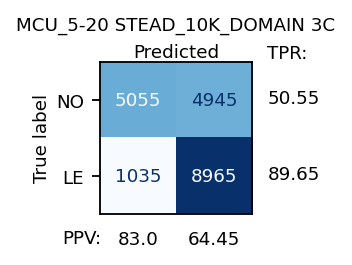

In [ ]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt

# Fungsi untuk membuat diagram batang metrik komprehensif
def plot_comprehensive_metrics(metrics, save_path):
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'Accuracy (avg.)', 
        'True positive rate (avg.)', 
        'Positive predictive value (avg.)', 
        'False positive rate (avg.)', 
        'F1-score (avg.)'
    ]
    values = [metrics.get(k, 0) for k in keys]
    print(f"[DEBUG] Nilai yang akan diplot: {values}") 

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (Average) - STEAD 10k')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik metrik komprehensif tersimpan di: {save_path}")

# Main execution
if __name__ == "__main__":

    #===================================================================
    #                    1. KONFIGURASI PATH STEAD 10K
    #===================================================================
    KEY_DATA_DIR = "/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_10000"
    KEY_TEST_FILE = 'STEAD_10k_3C_20260726_173059.json'  # Atau file JSON hasil konversi 10k siap benchmark
    DATA_TAG = "STEAD_10K_DOMAIN"
    MODEL_TAG = "MCU_5-20"
    INPUT_WIN = 7  # Jendela waktu dalam detik
    SAMPLING_RATE = 100
    
    # Label di JSON MCU-Quake benchmark: 'le' = Local Earthquake
    true_labels = ["NO", "LE"]  
    source_to_code = {"no": 0, "le": 1}  

    # Path Model dan Embedding
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    # Menggunakan embedding UUSS standar MCU-Quake
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")

    #===================================================================
    #                           2. PREPARE FILES
    #===================================================================
    print(f"[INFO] Memuat Dataset Benchmark STEAD 10k: {KEY_TEST_FILE}")
    json_path = os.path.join(KEY_DATA_DIR, KEY_TEST_FILE)
    test_data = dataset.load_json_data(json_path)
    
    # Buat folder output khusus benchmark 10k
    SAVE_BASE = "/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/benchmark_output_10k"
    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    if not os.path.exists(save_dir): 
        os.makedirs(save_dir)

    # Logger
    log_file_path = os.path.join(save_dir, "task_log_stead_10k.txt")
    logging.basicConfig(filename=log_file_path, level=logging.INFO, filemode='w',
                        format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # Load Model & Embeddings
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")

    logger.info(f"Estimating STEAD 10k embeddings statistics (KDE) using UUSS reference...")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

    #===================================================================
    #                            3. EVALUATION (3-COMPONENT 3C)
    #===================================================================
    total_true, total_pred = [], []
    num_points = int(INPUT_WIN * SAMPLING_RATE)
    keys_list = list(test_data.keys())

    logger.info(f"Memproses {len(keys_list)} data STEAD 10k (3C Pipeline)...")

    for i in tqdm(range(len(keys_list)), desc="Inference STEAD 10k"):
        record_key = keys_list[i]
        record = test_data[record_key]
        true_label = record["type"]  # 'le'
        
        try:
            # Ambil 3 komponen penuh (E, N, Z) sesuai struktur benchmark MCU-Quake
            E_n = record["E_noise"][-num_points:]
            N_n = record["N_noise"][-num_points:]
            Z_n = record["Z_noise"][-num_points:]

            E_s = record["E"][:num_points]
            N_s = record["N"][:num_points]
            Z_s = record["Z"][:num_points]

            # Latent codes untuk noise window (3 komponen)
            _in_En = utils.latent_codes_1D(E_n, embedding_model)
            _in_Nn = utils.latent_codes_1D(N_n, embedding_model)
            _in_Zn = utils.latent_codes_1D(Z_n, embedding_model)

            # Latent codes untuk signal window (3 komponen)
            _in_Es = utils.latent_codes_1D(E_s, embedding_model)
            _in_Ns = utils.latent_codes_1D(N_s, embedding_model)
            _in_Zs = utils.latent_codes_1D(Z_s, embedding_model)

            # Inferensi 3C untuk Noise Window
            emb_n = np.array([_in_En, _in_Nn, _in_Zn]).reshape(1, -1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            # Inferensi 3C untuk Signal Window
            emb_s = np.array([_in_Es, _in_Ns, _in_Zs]).reshape(1, -1)
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            # Mapping true label
            true_code = source_to_code.get(true_label, 1)  # Default ke 1 ('le')
            
            total_true.extend([0, 1]) 
            total_pred.extend([1 if p_n >= 1 else 0, 1 if p_s >= 1 else 0])
            
        except Exception as e:
            logger.error(f"Error pada trace {record_key}: {e}")
            continue

    #===================================================================
    #                        4. METRICS & SAVE
    #===================================================================
    matrix_3C, metrics_3C = utils.calc_confusion_metrics(total_true, total_pred)
    
    # Visualisasi Confusion Matrix
    fig_3C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 3C", true_labels, matrix_3C, metrics_3C)
    fig_3C.savefig(os.path.join(save_dir, "STEAD_10K_3C_confusion.jpg"), dpi=300)
    
    # Simpan metrics ke JSON
    dataset.save_json_data(os.path.join(save_dir, "stead_10k_metrics.json"), metrics_3C)
    
    # Plot comprehensive metrics bar chart
    plot_comprehensive_metrics(metrics_3C, os.path.join(save_dir, "stead_10K_3C_metrics_bar.jpg"))

    logger.info("\n" + "="*40)
    logger.info(f"STEAD 10K ACCURACY: {metrics_3C.get('accuracy (avg.)')}")
    logger.info(f"STEAD 10K F1-SCORE: {metrics_3C.get('f1-score (avg.)')}")
    logger.info("="*40)
    logger.info("Pengujian Benchmark STEAD 10k Selesai.")

[INFO] Memuat Dataset Benchmark STEAD 10k: STEAD_10k_3C_20260726_173059.json


2026-07-26 17:42:43,592 - [INFO]: Memuat model deep learning MCU-Quake 1D...


[INFO] Total trace yang dimuat: 10000


2026-07-26 17:42:43.632739: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-26 17:42:43.632810: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-26 17:42:43.632826: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-26 17:42:43.633038: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-26 17:42:43.633383: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-07-26 17:42:43,942 - [WARNING]: No training configuration found in save file, so the model was *not* compiled. Compile it manually.
2026-07-26 17:42:43,943 - [INFO]: Memuat data embedding referensi UUSS untuk 3 Komponen...
2026-07-26 17:42:44,215 - [INFO]: Membangun model probabilitas spasial (KDE 3D) berdasarkan UUSS...
2026-07-26 17:42:44,228 - [INFO]: ==================================================
2026-07-26 17:42:44,228 - [INFO]: Memulai iterasi inferensi pada 10000 data STEAD...
2026-07-26 17:42:44,228 - [INFO]: ==================================================
Inferensi STEAD 10k: 100%|██████████| 10000/10000 [04:03<00:00, 41.00it/s]
2026-07-26 17:46:48,167 - [INFO]: ==================================================
2026-07-26 17:46:48,172 - [INFO]: Mengkalkulasi Confusion Matrix dan Metrik Evaluasi...
2026-07-26 17:46:48,314 - [INFO]: Confusion Matrix disimpan di: /Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/benchmark_output_10k/MCU_5-20_STEAD_10K_DOMAIN_202607

Accuracy: [0.4752, 0.4752]
Accuracy (avg.): 0.4752
True positive rate: [0.35313333333333335, 0.8414]
True positive rate (avg.): 0.4752
True negative rate: [0.8414, 0.35313333333333335]
True negative rate (avg.): 0.7193333333333333
Positive predictive value: [0.8697865353037767, 0.30244428468727536]
Positive predictive value (avg.): 0.7279509726496514
Negative predictive value: [0.30244428468727536, 0.8697865353037767]
Negative predictive value (avg.): 0.44427984734140064
False positive rate: [0.1586, 0.6468666666666667]
False positive rate (avg.): 0.2806666666666667
False negative rate: [0.6468666666666667, 0.1586]
False negative rate (avg.): 0.5248
False discovery rate: [0.13021346469622333, 0.6975557153127246]
False discovery rate (avg.): 0.27204902735034864
F1-score: [0.5023233760075866, 0.4449497620306716]
F1-score (avg.): 0.48797997251335784
[DEBUG] Nilai yang akan diplot: [0.4752, 0.4752, 0.7279509726496514, 0.2806666666666667, 0.48797997251335784]


2026-07-26 17:46:48,478 - [INFO]: 
****************************************
2026-07-26 17:46:48,483 - [INFO]:   RINGKASAN PERFORMA - STEAD 10K 3C
2026-07-26 17:46:48,484 - [INFO]: ****************************************
2026-07-26 17:46:48,485 - [INFO]:   Akurasi (Accuracy) : 0.4752
2026-07-26 17:46:48,486 - [INFO]:   Presisi (Precision): 0.7280
2026-07-26 17:46:48,486 - [INFO]:   Sensitivitas (TPR) : 0.4752
2026-07-26 17:46:48,487 - [INFO]:   Skor F1 (F1-Score) : 0.4880
2026-07-26 17:46:48,488 - [INFO]:   Alarm Palsu (FPR)  : 0.2807
2026-07-26 17:46:48,488 - [INFO]: ****************************************
2026-07-26 17:46:48,492 - [INFO]: Pengujian Benchmark Selesai dengan Sukses.


[INFO] Grafik metrik komprehensif tersimpan di: /Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/benchmark_output_10k/MCU_5-20_STEAD_10K_DOMAIN_20260726_174243/STEAD_10K_3C_metrics_bar.jpg


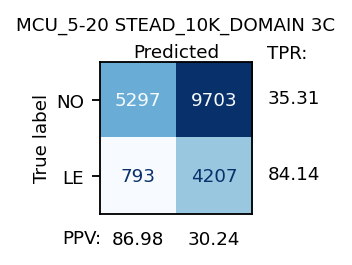

In [1]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
from datetime import datetime
import logging
import matplotlib.pyplot as plt

# Asumsi: Library utils dan dataset Anda sudah ada di direktori yang sama atau PYTHONPATH
from Library import utils, dataset

# ===================================================================
# FUNGSI VISUALISASI METRIK KOMPREHENSIF
# ===================================================================
def plot_comprehensive_metrics(metrics, save_path):
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'Accuracy (avg.)', 
        'True positive rate (avg.)', 
        'Positive predictive value (avg.)', 
        'False positive rate (avg.)', 
        'F1-score (avg.)'
    ]
    values = [metrics.get(k, 0) for k in keys]
    print(f"[DEBUG] Nilai yang akan diplot: {values}") 

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (Average) - STEAD 10k Benchmark')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Menambahkan label nilai di atas setiap batang
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
        
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik metrik komprehensif tersimpan di: {save_path}")

# ===================================================================
# MAIN EXECUTION
# ===================================================================
if __name__ == "__main__":

    # -------------------------------------------------------------------
    # 1. KONFIGURASI PATH DAN PARAMETER (SESUAIKAN DENGAN WORKSTATION ANDA)
    # -------------------------------------------------------------------
    KEY_DATA_DIR = "/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_10000"
    KEY_TEST_FILE = 'STEAD_10k_3C_20260726_173059.json' # Ganti dengan nama file JSON hasil ekstraksi Anda yang sesungguhnya
    
    DATA_TAG = "STEAD_10K_DOMAIN"
    MODEL_TAG = "MCU_5-20"
    
    INPUT_WIN = 7  # Jendela waktu dalam detik (standar MCU-Quake)
    SAMPLING_RATE = 100 # 100 Hz
    num_points = int(INPUT_WIN * SAMPLING_RATE) # 700 titik sampel
    
    # Label kelas: 'no' (Noise) = 0, 'le' (Local Earthquake) = 1
    true_labels = ["NO", "LE"]  
    source_to_code = {"no": 0, "le": 1}  

    # Direktori Model dan Embedding Referensi (UUSS)
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")

    # -------------------------------------------------------------------
    # 2. PERSIAPAN FILE DAN LOGGER
    # -------------------------------------------------------------------
    print(f"[INFO] Memuat Dataset Benchmark STEAD 10k: {KEY_TEST_FILE}")
    json_path = os.path.join(KEY_DATA_DIR, KEY_TEST_FILE)
    
    # Memuat data uji (pastikan load_json_data menangani exception jika file tidak ada)
    test_data = dataset.load_json_data(json_path)
    keys_list = list(test_data.keys())
    print(f"[INFO] Total trace yang dimuat: {len(keys_list)}")

    # Setup folder output dengan penanda waktu
    SAVE_BASE = '/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/benchmark_output_10k'
    time_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    os.makedirs(save_dir, exist_ok=True)

    # Konfigurasi sistem logging
    log_file_path = os.path.join(save_dir, "task_log_stead_10k.txt")
    logging.basicConfig(level=logging.INFO,
                        format='%(asctime)s - [%(levelname)s]: %(message)s',
                        handlers=[
                            logging.FileHandler(log_file_path, mode='w'),
                            logging.StreamHandler()
                        ])
    logger = logging.getLogger()

    # -------------------------------------------------------------------
    # 3. MEMUAT MODEL DAN ESTIMASI KDE (KERNEL DENSITY ESTIMATION)
    # -------------------------------------------------------------------
    logger.info("Memuat model deep learning MCU-Quake 1D...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    
    logger.info("Memuat data embedding referensi UUSS untuk 3 Komponen...")
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")

    logger.info("Membangun model probabilitas spasial (KDE 3D) berdasarkan UUSS...")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)


    # -------------------------------------------------------------------
    # 4. PROSES INFERENSI (EVALUASI 3-KOMPONEN)
    # -------------------------------------------------------------------
    total_true = []
    total_pred = []
    
    logger.info("="*50)
    logger.info(f"Memulai iterasi inferensi pada {len(keys_list)} data STEAD...")
    logger.info("="*50)

    for i in tqdm(range(len(keys_list)), desc="Inferensi STEAD 10k"):
        record_key = keys_list[i]
        record = test_data[record_key]
        
        # 'le' untuk gempa lokal, 'no' untuk noise
        true_label = record.get("type", "unknown") 
        
        try:
            # Slicing input window (700 sampel), pastikan data sudah ter-detrend dan ternormalisasi
            E_n = np.array(record["E_noise"][:num_points])
            N_n = np.array(record["N_noise"][:num_points])
            Z_n = np.array(record["Z_noise"][:num_points])

            E_s = np.array(record["E"][:num_points])
            N_s = np.array(record["N"][:num_points])
            Z_s = np.array(record["Z"][:num_points])

            # Ekstraksi Latent Codes untuk Noise Window (Jendela Pra-P)
            _in_En = utils.latent_codes_1D(E_n, embedding_model)
            _in_Nn = utils.latent_codes_1D(N_n, embedding_model)
            _in_Zn = utils.latent_codes_1D(Z_n, embedding_model)

            # Ekstraksi Latent Codes untuk Signal Window (Jendela Utama)
            _in_Es = utils.latent_codes_1D(E_s, embedding_model)
            _in_Ns = utils.latent_codes_1D(N_s, embedding_model)
            _in_Zs = utils.latent_codes_1D(Z_s, embedding_model)

            # Inferensi KDE 3C untuk Noise Window
            emb_n = np.array([_in_En, _in_Nn, _in_Zn]).reshape(1, -1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            # Inferensi KDE 3C untuk Signal Window
            emb_s = np.array([_in_Es, _in_Ns, _in_Zs]).reshape(1, -1)
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            # Logika Pelabelan Ground Truth Dinamis
            # Jendela prepick (noise) selalu bernilai 0 (Noise)
            true_n_class = 0 
            # Jendela utama bernilai 1 jika gempa ('le'), dan 0 jika ia memang noise murni ('no')
            true_s_class = 1 if true_label == "le" else 0
            
            # Tambahkan Ground Truth ke list
            total_true.extend([true_n_class, true_s_class]) 
            
            # Tambahkan Prediksi Model (Asumsi p >= 1.0 berarti Gempa)
            total_pred.extend([1 if p_n >= 1.0 else 0, 1 if p_s >= 1.0 else 0])
            
        except Exception as e:
            logger.error(f"Pengecualian (Error) pada trace {record_key}: {e}")
            continue

    # -------------------------------------------------------------------
    # 5. KALKULASI METRIK & PENYIMPANAN VISUALISASI
    # -------------------------------------------------------------------
    logger.info("="*50)
    logger.info("Mengkalkulasi Confusion Matrix dan Metrik Evaluasi...")
    
    # Hitung metrik komprehensif menggunakan utils
    matrix_3C, metrics_3C = utils.calc_confusion_metrics(total_true, total_pred)
    
    # Simpan Gambar Confusion Matrix
    conf_matrix_path = os.path.join(save_dir, "STEAD_10K_3C_confusion.jpg")
    fig_3C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 3C", true_labels, matrix_3C, metrics_3C)
    fig_3C.savefig(conf_matrix_path, dpi=300)
    logger.info(f"Confusion Matrix disimpan di: {conf_matrix_path}")
    
    # Simpan JSON Metrics
    metrics_json_path = os.path.join(save_dir, "stead_10k_metrics.json")
    dataset.save_json_data(metrics_json_path, metrics_3C)
    logger.info(f"Detail metrik JSON disimpan di: {metrics_json_path}")
    
    # Buat Bar Chart Komprehensif
    bar_chart_path = os.path.join(save_dir, "STEAD_10K_3C_metrics_bar.jpg")
    plot_comprehensive_metrics(metrics_3C, bar_chart_path)

    # Ringkasan di Terminal
    logger.info("\n" + "*"*40)
    logger.info(f"  RINGKASAN PERFORMA - STEAD 10K 3C")
    logger.info("*"*40)
    logger.info(f"  Akurasi (Accuracy) : {metrics_3C.get('Accuracy (avg.)', 0):.4f}")
    logger.info(f"  Presisi (Precision): {metrics_3C.get('Positive predictive value (avg.)', 0):.4f}")
    logger.info(f"  Sensitivitas (TPR) : {metrics_3C.get('True positive rate (avg.)', 0):.4f}")
    logger.info(f"  Skor F1 (F1-Score) : {metrics_3C.get('F1-score (avg.)', 0):.4f}")
    logger.info(f"  Alarm Palsu (FPR)  : {metrics_3C.get('False positive rate (avg.)', 0):.4f}")
    logger.info("*"*40)
    logger.info("Pengujian Benchmark Selesai dengan Sukses.")